# PHYS 449 - Homework 1, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, September 11, 3:00pm 
- - -


2. Consider the provided Python code for a 2D Ising model with N = 256
spins on a 16 × 16 periodic lattice:

100%|██████████| 30/30 [01:10<00:00,  2.36s/it]


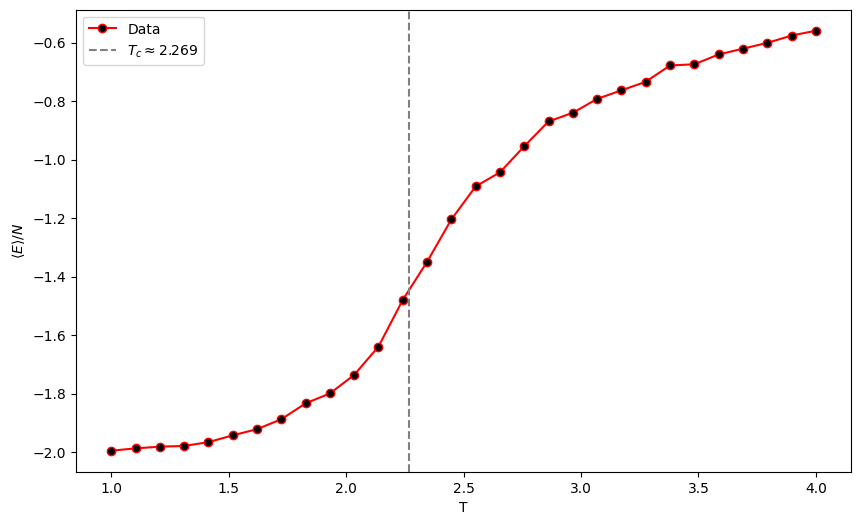

In [6]:
"""
PHYS 449, F25, Homework 1, Problem 2
Monte Carlo program for the 2D Ising model

"""

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


def init_spins(L):
    return np.random.choice([-1, 1], size=(L, L))


def total_energy(spins, L, J):
    E = 0
    for i in range(L):
        for j in range(L):
            E += spins[i, j] * spins[i, (j + 1) % L]
            E += spins[i, j] * spins[(i + 1) % L, j]
    return -J * E


def energy_difference(spins, L, J, x, y):
    sigma_old = spins[x, y]

    sum_neighbors = (
        spins[(x + 1) % L, y]  # Bottom
        + spins[(x - 1) % L, y]  # Top
        + spins[x, (y + 1) % L]  # Right
        + spins[x, (y - 1) % L]  # Left
    )

    dE = 2 * J * sigma_old * sum_neighbors
    return dE


def metropolis_accept(deltaE, T):
    if deltaE < 0:
        return True
    else:
        acceptance_prob = np.exp(-deltaE / T)
        return acceptance_prob > np.random.rand()


def run_mcmc(L, n_samples, temperature, J=1.0):
    spins = init_spins(L)
    N = L * L

    current_energy = total_energy(spins, L, J)

    energies = []
    samples = []

    for sample in range(n_samples):
        for flip in range(N):
            x, y = np.random.randint(0, L, size=2)
            dE = energy_difference(spins, L, J, x, y)
            if metropolis_accept(dE, temperature):
                spins[x, y] *= -1
                current_energy += dE
        energies.append(current_energy)
        samples.append(spins.copy())

    return samples, energies


if __name__ == "__main__":
    L = 10
    N = L * L
    n_sweeps = 2000
    J = 1.0

    plt.style.use("default")

    temperatures = np.linspace(1.0, 4.0, 30)
    avg_energies = []

    for T in tqdm(temperatures):
        samples, energies = run_mcmc(L, n_sweeps, T, J)

        mean_energy_per_spin = np.mean(energies) / N
        avg_energies.append(mean_energy_per_spin)

    Tc = 2.269 * J

    plt.figure(figsize=(10, 6))
    plt.plot(
        temperatures,
        avg_energies,
        "o-",
        label="Data",
        color="red",
        markerfacecolor="black",
    )
    plt.axvline(x=Tc, color="gray", linestyle="--", label=f"$T_c \\approx {Tc:.3f}$")

    plt.xlabel("T")
    plt.ylabel(r"$\langle E \rangle / N$")
    plt.legend()
    plt.show()


(a) Produce a dataset for *T* = 1.0, 2.7 and 4.0, consisting of vectors of length *N* for
each configuration of spins. The cardinality of each dataset should be $10^{4}$.

 33%|███▎      | 1/3 [00:29<00:59, 29.64s/it]

Saved (10000, 256) dataset for T=1.0


 67%|██████▋   | 2/3 [00:59<00:29, 29.59s/it]

Saved (10000, 256) dataset for T=2.7


100%|██████████| 3/3 [01:29<00:00, 29.93s/it]

Saved (10000, 256) dataset for T=4.0


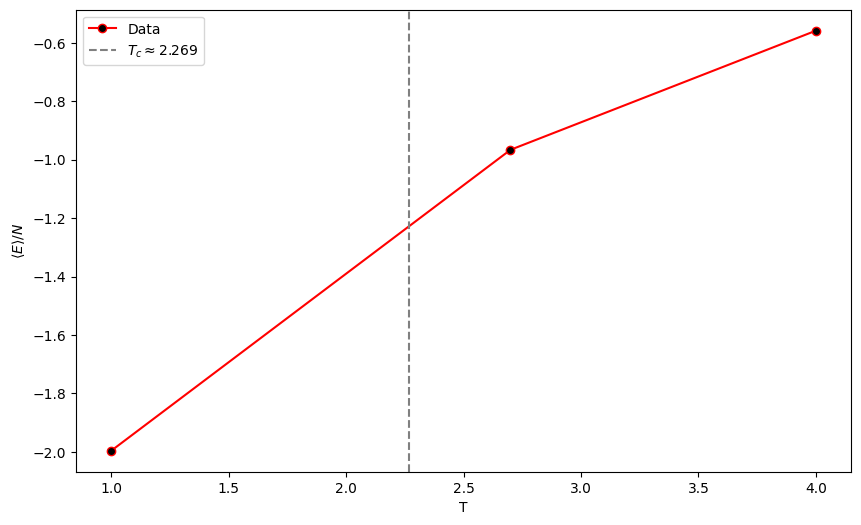

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


def init_spins(L):
    return np.random.choice([-1, 1], size=(L, L))


def total_energy(spins, L, J):
    E = 0
    for i in range(L):
        for j in range(L):
            E += spins[i, j] * spins[i, (j + 1) % L]
            E += spins[i, j] * spins[(i + 1) % L, j]
    return -J * E


def energy_difference(spins, L, J, x, y):
    sigma_old = spins[x, y]

    sum_neighbors = (
        spins[(x + 1) % L, y]  # Bottom
        + spins[(x - 1) % L, y]  # Top
        + spins[x, (y + 1) % L]  # Right
        + spins[x, (y - 1) % L]  # Left
    )

    dE = 2 * J * sigma_old * sum_neighbors
    return dE


def metropolis_accept(deltaE, T):
    if deltaE < 0:
        return True
    else:
        acceptance_prob = np.exp(-deltaE / T)
        return acceptance_prob > np.random.rand()


def run_mcmc(L, n_samples, temperature, J=1.0):
    spins = init_spins(L)
    N = L * L

    current_energy = total_energy(spins, L, J)

    energies = []
    samples = []

    for sample in range(n_samples):
        for flip in range(N):
            x, y = np.random.randint(0, L, size=2)
            dE = energy_difference(spins, L, J, x, y)
            if metropolis_accept(dE, temperature):
                spins[x, y] *= -1
                current_energy += dE
        energies.append(current_energy)
        samples.append(spins.copy())

    return samples, energies


if __name__ == "__main__":
    L = 16
    N = L * L
    n_sweeps = 10000
    J = 1.0

    plt.style.use("default")

    temperatures = [1.0, 2.7, 4.0]
    avg_energies = []

    for T in tqdm(temperatures):
        samples, energies = run_mcmc(L, n_sweeps, T, J)

        X = np.array(samples).reshape(n_sweeps, -1)  # shape (10000, 256)
        np.save(f"ising_L16_T{T:.1f}.npy", X)
        print(f"Saved {X.shape} dataset for T={T}")

        mean_energy_per_spin = np.mean(energies) / N
        avg_energies.append(mean_energy_per_spin)

    Tc = 2.269 * J

    plt.figure(figsize=(10, 6))
    plt.plot(
        temperatures,
        avg_energies,
        "o-",
        label="Data",
        color="red",
        markerfacecolor="black",
    )
    plt.axvline(x=Tc, color="gray", linestyle="--", label=f"$T_c \\approx {Tc:.3f}$")

    plt.xlabel("T")
    plt.ylabel(r"$\langle E \rangle / N$")
    plt.legend()
    plt.show()


(b) Calculate the mean and standard deviation of the energy and magnetization for
each dataset.

In [11]:
import numpy as np

L = 16
N = L * L
temps = [1.0, 2.7, 4.0]
J = 1.0

def config_energy(config, L=16, J=1.0):
    spins = config.reshape(L, L)
    return total_energy(spins, L, J)

def config_magnetization(config):
    return np.sum(config)

for T in temps:
    X = np.load(f"ising_L16_T{T:.1f}.npy")  # (10000, 256)

    energies = np.array([config_energy(cfg, L, J) for cfg in X])
    mags     = np.array([config_magnetization(cfg) for cfg in X])

    print(f"T = {T}")
    print(f"  Energy: mean = {energies.mean():.3f}, std = {energies.std(ddof=1):.3f}")
    print(f"  Magnetization: mean = {mags.mean():.3f}, std = {mags.std(ddof=1):.3f}")


T = 1.0
  Energy: mean = -511.007, std = 6.025
  Magnetization: mean = -255.514, std = 6.514
T = 2.7
  Energy: mean = -247.393, std = 35.232
  Magnetization: mean = 5.054, std = 79.006
T = 4.0
  Energy: mean = -143.082, std = 26.570
  Magnetization: mean = 2.164, std = 33.816


(c) Are your dataset sample *i.i.d.*? Define and measure an autocorrelation time for
each dataset.

In [12]:
import numpy as np

def autocorr_1d(x, max_lag=None):
    """Normalized autocorrelation using FFT."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    x -= x.mean()
    f = np.fft.rfft(x, n=2*n)
    acf = np.fft.irfft(f * np.conj(f))[:n]
    acf /= acf[0]
    if max_lag is None:
        return acf
    else:
        return acf[:max_lag+1]

def integrated_autocorr_time(rho, c=5.0):
    """Sokal’s automatic windowing."""
    tau = 0.5
    for t in range(1, len(rho)):
        tau_new = 0.5 + np.sum(rho[1:t+1])
        if t > c * tau_new:
            break
        tau = tau_new
    return tau

L = 16
temps = [1.0, 2.7, 4.0]

for T in temps:
    X = np.load(f"ising_L16_T{T:.1f}.npy")
    energies = np.array([config_energy(cfg, L) for cfg in X])
    mags     = np.array([config_magnetization(cfg) for cfg in X])

    # autocorrelation functions
    rhoE = autocorr_1d(energies, max_lag=2000)
    rhoM = autocorr_1d(mags,     max_lag=2000)

    tauE = integrated_autocorr_time(rhoE)
    tauM = integrated_autocorr_time(rhoM)

    print(f"T = {T}")
    print(f"  tau_E ≈ {tauE:.1f}")
    print(f"  tau_M ≈ {tauM:.1f}")


T = 1.0
  tau_E ≈ 7.7
  tau_M ≈ 10.1
T = 2.7
  tau_E ≈ 5.3
  tau_M ≈ 33.8
T = 4.0
  tau_E ≈ 1.0
  tau_M ≈ 3.6


(d) Recalculate your mean and standard deviation, corrected to account for the autocorrelation time.

In [13]:
import numpy as np

L, N, J = 16, 16*16, 1.0
temps = [1.0, 2.7, 4.0]

def config_energy(config, L=16, J=1.0):
    spins = config.reshape(L, L)
    # right + down neighbors once, periodic
    E = np.sum(spins * np.roll(spins, -1, axis=1)) + np.sum(spins * np.roll(spins, -1, axis=0))
    return -J * E

def config_magnetization(config):
    return np.sum(config)

def autocorr_1d(x, max_lag=None):
    x = np.asarray(x, float)
    x -= x.mean()
    n = len(x)
    f = np.fft.rfft(x, n=2*n)
    acf = np.fft.irfft(f * np.conj(f))[:n]
    acf /= acf[0]
    return acf if max_lag is None else acf[:max_lag+1]

def integrated_autocorr_time(rho, c=5.0):
    tau = 0.5
    for t in range(1, len(rho)):
        tau_new = 0.5 + np.sum(rho[1:t+1])
        if t > c * tau_new:
            break
        tau = tau_new
    return max(tau, 0.5)  # be safe against tiny/negative estimates

def corrected_stats(series, tau):
    n = len(series)
    mu = series.mean()
    var = series.var(ddof=1)
    neff = n / (2.0 * tau)
    se = np.sqrt(var / neff)
    return mu, se, neff, var

for T in temps:
    X = np.load(f"ising_L16_T{T:.1f}.npy")       # (10000, 256)
    E = np.array([config_energy(cfg, L, J) for cfg in X])
    M = np.array([config_magnetization(cfg) for cfg in X])

    # (b) naive
    E_mean_naive, E_std_naive = E.mean(), E.std(ddof=1)
    M_mean_naive, M_std_naive = M.mean(), M.std(ddof=1)

    # (c) taus
    tauE = integrated_autocorr_time(autocorr_1d(E, max_lag=2000))
    tauM = integrated_autocorr_time(autocorr_1d(M, max_lag=2000))

    # (d) correlation-corrected mean ± SE and Neff
    E_mean, E_se, E_neff, _ = corrected_stats(E, tauE)
    M_mean, M_se, M_neff, _ = corrected_stats(M, tauM)

    # per-spin versions
    Ep_mean, Ep_se = E_mean/N, E_se/N
    Mp_mean, Mp_se = M_mean/N, M_se/N

    print(f"\nT = {T:.1f}  (N_samp = {len(E)}, N = {N})")
    print(f"Naive (total):    <E> = {E_mean_naive:8.3f} ± {E_std_naive:7.3f} (sd), "
          f"<M> = {M_mean_naive:8.3f} ± {M_std_naive:7.3f} (sd)")
    print(f"taus:             tau_E = {tauE:5.1f}, tau_M = {tauM:5.1f}")
    print(f"Corrected (total):<E> = {E_mean:8.3f} ± {E_se:7.3f} (SE, N_eff={E_neff:6.0f}), "
          f"<M> = {M_mean:8.3f} ± {M_se:7.3f} (SE, N_eff={M_neff:6.0f})")
    print(f"Per spin:         <E/N> = {Ep_mean:8.4f} ± {Ep_se:7.4f}, "
          f"<M/N> = {Mp_mean:8.4f} ± {Mp_se:7.4f}")



T = 1.0  (N_samp = 10000, N = 256)
Naive (total):    <E> = -511.007 ±   6.025 (sd), <M> = -255.514 ±   6.514 (sd)
taus:             tau_E =   7.7, tau_M =  10.1
Corrected (total):<E> =    0.000 ±   0.237 (SE, N_eff=   648), <M> = -255.514 ±   0.293 (SE, N_eff=   495)
Per spin:         <E/N> =   0.0000 ±  0.0009, <M/N> =  -0.9981 ±  0.0011

T = 2.7  (N_samp = 10000, N = 256)
Naive (total):    <E> = -247.393 ±  35.232 (sd), <M> =    5.054 ±  79.006 (sd)
taus:             tau_E =   5.3, tau_M =  33.8
Corrected (total):<E> =    0.000 ±   1.150 (SE, N_eff=   939), <M> =    5.054 ±   6.492 (SE, N_eff=   148)
Per spin:         <E/N> =   0.0000 ±  0.0045, <M/N> =   0.0197 ±  0.0254

T = 4.0  (N_samp = 10000, N = 256)
Naive (total):    <E> = -143.082 ±  26.570 (sd), <M> =    2.164 ±  33.816 (sd)
taus:             tau_E =   1.0, tau_M =   3.6
Corrected (total):<E> =   -0.000 ±   0.376 (SE, N_eff=  4997), <M> =    2.164 ±   0.914 (SE, N_eff=  1370)
Per spin:         <E/N> =  -0.0000 ±  0.0015, <

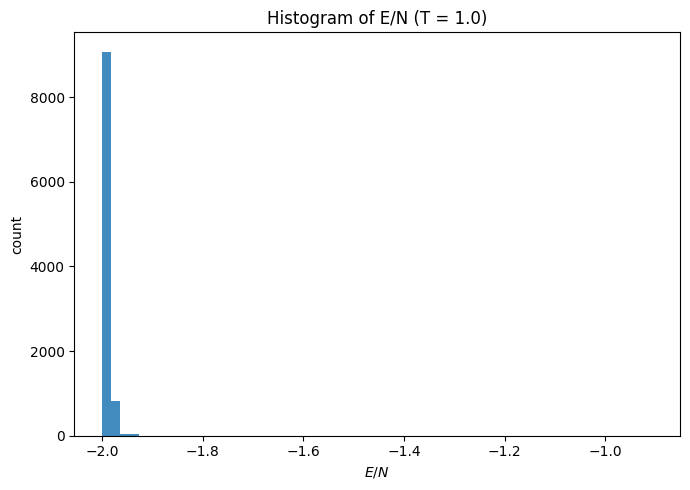

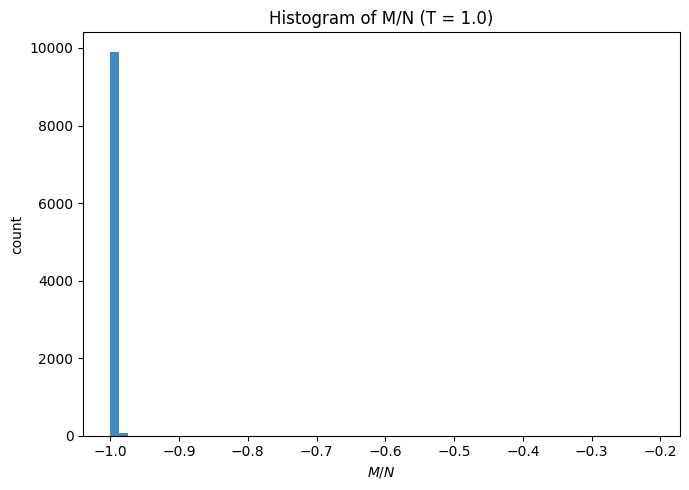

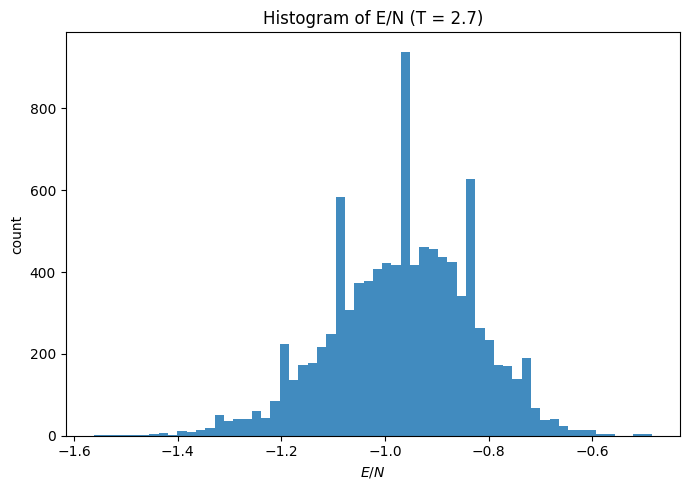

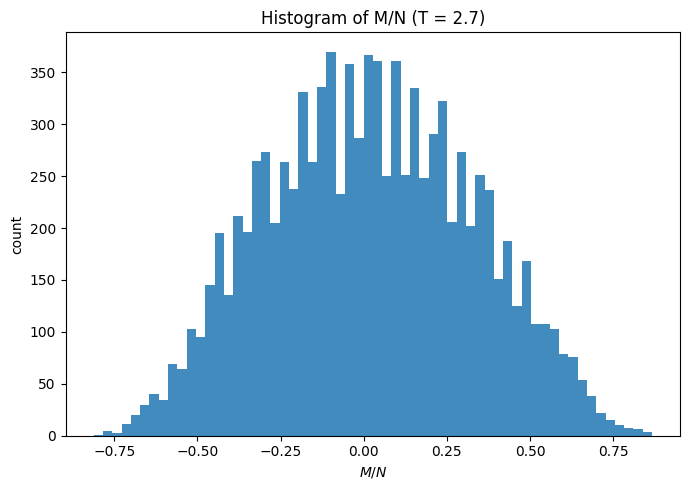

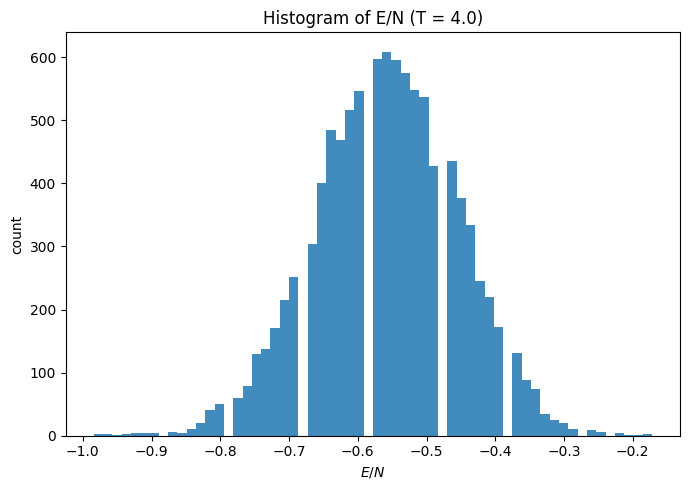

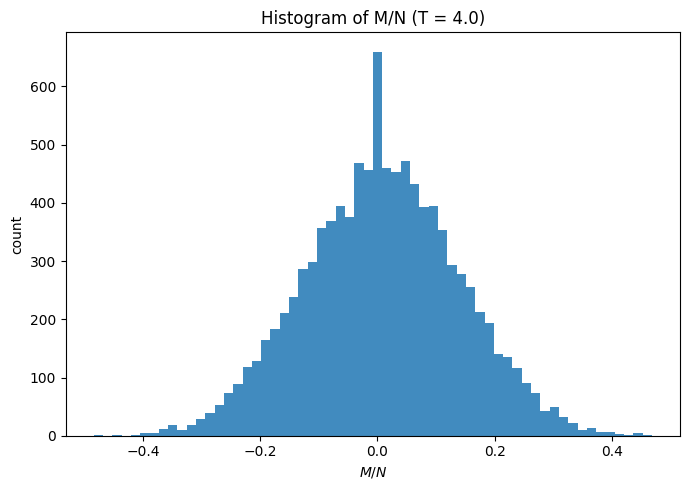

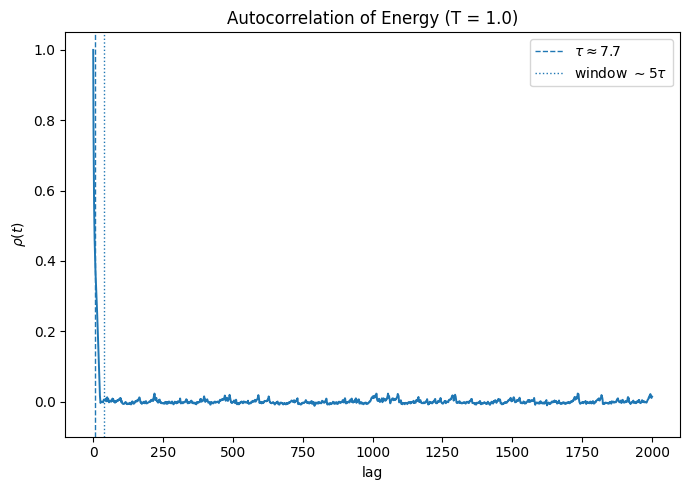

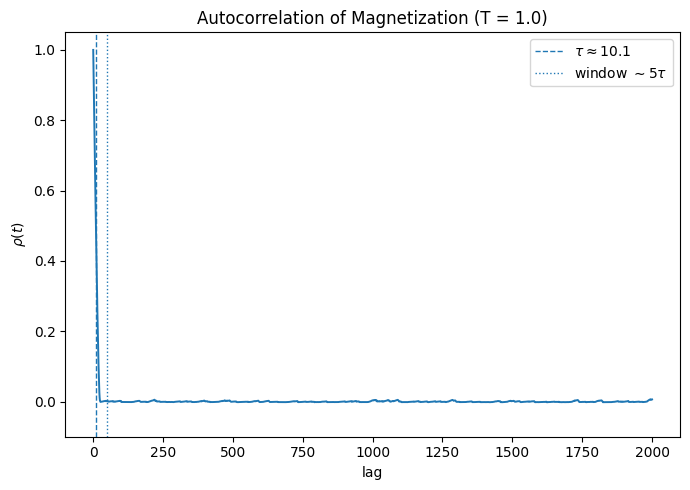

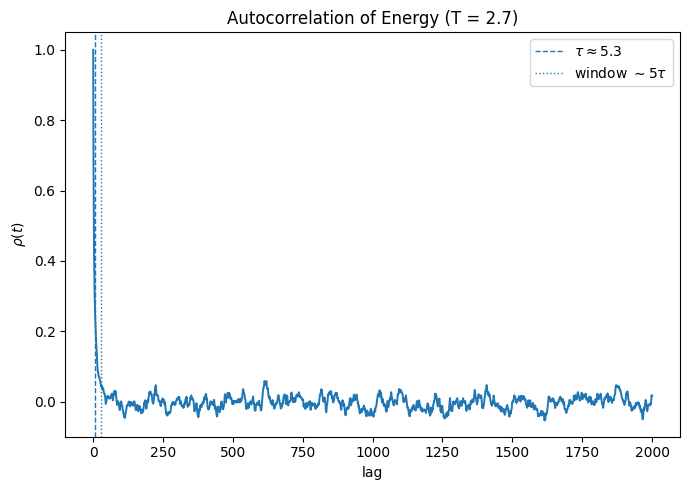

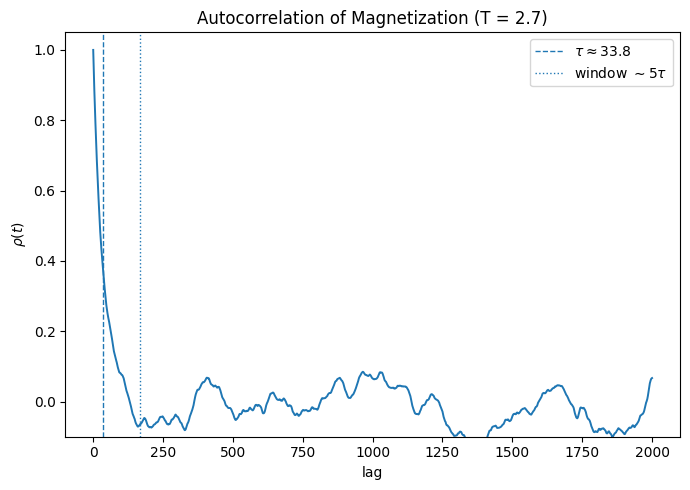

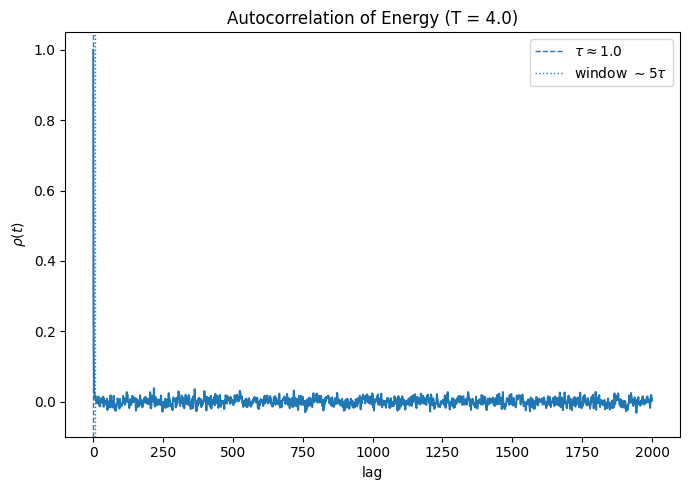

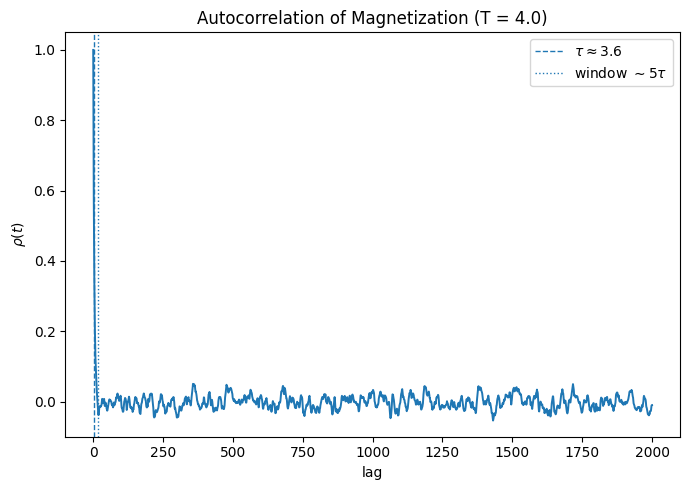

In [14]:
import numpy as np
import matplotlib.pyplot as plt

L, N, J = 16, 16*16, 1.0
temps = [1.0, 2.7, 4.0]

def load_stats_for_T(T):
    X = np.load(f"ising_L16_T{T:.1f}.npy")
    E = np.array([config_energy(cfg, L, J) for cfg in X])
    M = np.array([config_magnetization(cfg) for cfg in X])
    Ep, Mp = E / N, M / N
    rhoE = autocorr_1d(E,  max_lag=min(2000, len(E)-1))
    rhoM = autocorr_1d(M,  max_lag=min(2000, len(M)-1))
    tauE = integrated_autocorr_time(rhoE)
    tauM = integrated_autocorr_time(rhoM)
    return Ep, Mp, rhoE, rhoM, tauE, tauM

# ---------- 1) Histograms of E/N and M/N ----------
for T in temps:
    Ep, Mp, rhoE, rhoM, tauE, tauM = load_stats_for_T(T)

    plt.figure(figsize=(7,5))
    plt.hist(Ep, bins=60, alpha=0.85)
    plt.xlabel(r"$E/N$")
    plt.ylabel("count")
    plt.title(f"Histogram of E/N (T = {T:.1f})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.hist(Mp, bins=60, alpha=0.85)
    plt.xlabel(r"$M/N$")
    plt.ylabel("count")
    plt.title(f"Histogram of M/N (T = {T:.1f})")
    plt.tight_layout()
    plt.show()

# ---------- 2) Autocorrelation curves with τ markers ----------
def plot_acf(rho, tau, label, T):
    plt.figure(figsize=(7,5))
    lags = np.arange(len(rho))
    plt.plot(lags, rho, lw=1.4)
    # mark tau and window cutoff ~ 5*tau (same c as in estimator)
    plt.axvline(tau,    ls="--", lw=1.0, label=fr"$\tau \approx {tau:.1f}$")
    plt.axvline(5*tau,  ls=":",  lw=1.0, label=fr"window $\sim 5\tau$")
    plt.xlabel("lag")
    plt.ylabel(r"$\rho(t)$")
    plt.ylim(-0.1, 1.05)
    plt.title(f"Autocorrelation of {label} (T = {T:.1f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

for T in temps:
    Ep, Mp, rhoE, rhoM, tauE, tauM = load_stats_for_T(T)
    plot_acf(rhoE, tauE, "Energy", T)
    plot_acf(rhoM, tauM, "Magnetization", T)
